# N08 - Quantum Rabi Regime Map
## Rotating-wave, dispersive, displaced-oscillator, multiphoton, and critical descriptions

The quantum Rabi Hamiltonian supports several controlled effective theories because the natural basis, retained manifold, observable, and timescale change with the physical question. This notebook is the computational companion to the article's regime-map section.

$$
\boxed{\text{one microscopic model}\;\not\Rightarrow\;\text{one universal effective Hamiltonian}.}
$$

QuTiP is used for all Hilbert-space operators, eigenstates, dynamics, partial traces, displacements, and Wigner functions. NumPy and pandas organize scalar diagnostics and archived data; SciPy is not used as a replacement for a QuTiP operation.

## 1. Learning goals and claim-diagnostic map

After completing N08, the reader should be able to:

1. construct the quantum Rabi and Jaynes--Cummings Hamiltonians with a fixed tensor convention;
2. verify that excitation number is not conserved while parity is exact;
3. explain why RWA accuracy depends on state, occupied sector, observable, and time;
4. verify the fourth-order spectral error of a second-order dispersive prediction;
5. observe the reorganization from bare excitation manifolds to displaced-oscillator parity doublets;
6. distinguish bare oscillator occupation, fluctuations above displaced wells, and detector-defined excitations;
7. identify a selected multiphoton resonance as a local retained manifold rather than a fifth global asymptotic regime;
8. distinguish a finite-frequency crossover from the singular large-frequency-ratio quantum-critical limit.

| Claim | Primary diagnostic | First failure or repair |
|---|---|---|
| near-resonant RWA | state fidelity and sector population | retain counter-rotating terms or use a dressed basis |
| dispersive JC model | state-dependent mixing and spectral error | retain the resonant doublet when a denominator closes |
| displaced/GRWA organization | low-energy subspace fidelity and parity doublets | enlarge the displaced block near additional avoided crossings |
| virtual photons | detector-positive-frequency operator | transform the observable and system-bath coupling |
| critical QRM scaling | soft-mode gap at fixed scaled coupling | distinguish finite-ratio crossover from the singular limit |

## 2. Reproducible setup

The main reader-editable controls are the oscillator cutoff `N_CAV`, the resonant frequencies `OMEGA_A` and `OMEGA_0`, and the coupling grids. The default cutoff is intentionally larger than the displaced occupation at the largest displayed coupling and is checked independently at the end.

In [2]:
from pathlib import Path
import json
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots  # noqa: F401

import qutip as qt
from qutip import (
    basis, coherent, destroy, displace, expect, ket2dm, qeye,
    sesolve, sigmam, sigmap, sigmax, sigmaz, tensor, wigner,
)

version = tuple(int(x) for x in qt.__version__.split(".")[:2])
if version < (5, 2):
    raise RuntimeError(f"N08 requires QuTiP 5.2 or newer; found {qt.__version__}.")

plt.style.use(["science", "notebook"])

# Figure typography and geometry for a 150 mm manuscript column.
# Matplotlib ships cmr10, which closely matches the Computer Modern family
# used by the default LaTeX ``article`` class.
FIG_WIDTH_150MM = 150.0 / 25.4
SCIPOST_FONT_SIZE = 10.95  # LaTeX article class with option 11pt
plt.rcParams.update({
    # Figure
    "figure.dpi": 150,
    "savefig.dpi": 600,

    # Let LaTeX render both text and mathematics
    "text.usetex": True,

    # SciPost.cls -> article[11pt] -> default Computer Modern
    "font.family": "serif",

    # Match LaTeX's \normalsize for article[11pt]
    "font.size": SCIPOST_FONT_SIZE,
    "axes.labelsize": SCIPOST_FONT_SIZE,
    "axes.titlesize": SCIPOST_FONT_SIZE,
    "legend.fontsize": SCIPOST_FONT_SIZE,
    "xtick.labelsize": SCIPOST_FONT_SIZE,
    "ytick.labelsize": SCIPOST_FONT_SIZE,

    # Plot styling
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.35,
    "lines.markersize": 4.2,

    # Same math packages loaded/compatible with SciPost
    "text.latex.preamble": r"\usepackage{amsmath}",
})

ROOT = Path.cwd()
FIG_MANUSCRIPT = ROOT / "figures" / "manuscript"
FIG_NOTEBOOK = ROOT / "figures" / "notebook"
DATA = ROOT / "data"
for directory in (FIG_MANUSCRIPT, FIG_NOTEBOOK, DATA):
    directory.mkdir(parents=True, exist_ok=True)

def save_figure(fig, stem, manuscript=False):
    directory = FIG_MANUSCRIPT if manuscript else FIG_NOTEBOOK
    modified_stem = f"{stem}_modified"
    fig.savefig(
        directory / f"{modified_stem}.pdf",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.03,
    )
    # Keep the notebook preview/export path available at the same publication resolution.
    fig.savefig(
        directory / f"{modified_stem}.png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.03,
    )

def save_table(frame, stem):
    frame.to_csv(DATA / f"{stem}.csv", index=False)

N_CAV = 70
OMEGA_A = 1.0
OMEGA_0 = 1.0
I_Q, I_C = qeye(2), qeye(N_CAV)
a = tensor(I_Q, destroy(N_CAV))
n = a.dag() * a
sx = tensor(sigmax(), I_C)
sz = tensor(sigmaz(), I_C)
sp = tensor(sigmap(), I_C)
sm = tensor(sigmam(), I_C)

parity_cavity = qt.Qobj(np.diag((-1.0) ** np.arange(N_CAV)), dims=[[N_CAV], [N_CAV]])
parity = tensor(-sigmaz(), parity_cavity)
number = n + sp * sm

def rabi_hamiltonian(g, omega_a=OMEGA_A, omega_0=OMEGA_0):
    return omega_a * n + 0.5 * omega_0 * sz + g * sx * (a + a.dag())

def jc_hamiltonian(g, omega_a=OMEGA_A, omega_0=OMEGA_0):
    return omega_a * n + 0.5 * omega_0 * sz + g * (sp * a + sm * a.dag())

H_test = rabi_hamiltonian(0.37)
parity_residual = (H_test * parity - parity * H_test).norm()
number_residual = (H_test * number - number * H_test).norm()

print(f"Python {sys.version.split()[0]}")
print(f"QuTiP {qt.__version__}")
print(f"Parity commutator norm: {parity_residual:.3e}")
print(f"Excitation-number commutator norm: {number_residual:.3e}")

Python 3.11.9
QuTiP 5.2.0
Parity commutator norm: 0.000e+00
Excitation-number commutator norm: 5.714e+02


## 3. Canonical article regime map

The diagram below is a map of distinct scale separations, not a ladder of successively more accurate approximations. A selected three-photon resonance is shown as a local retained block because it can arise inside more than one global parameter regime.

In [3]:
from hashlib import sha256
from pathlib import Path

asset_pdf = Path("assets/manuscript/N08_MF1.pdf")
asset_png = Path("assets/manuscript/N08_MF1.png")
target_dir = Path("figures/manuscript")
target_pdf = target_dir / "N08_MF1.pdf"

hash_pdf = sha256(asset_pdf.read_bytes()).hexdigest()
hash_png = sha256(asset_png.read_bytes()).hexdigest()
hash_target = sha256(target_pdf.read_bytes()).hexdigest()
print(hash_pdf)
print(hash_png)
print(hash_target)

458c41000f44a38209627d236ad9054c858623f42b5daa64bed350b8a5a9d6d1
9db2be1a7e761dac3fa0873708d332bfbbb3008384bed64936a9833b6b27cd80
458c41000f44a38209627d236ad9054c858623f42b5daa64bed350b8a5a9d6d1


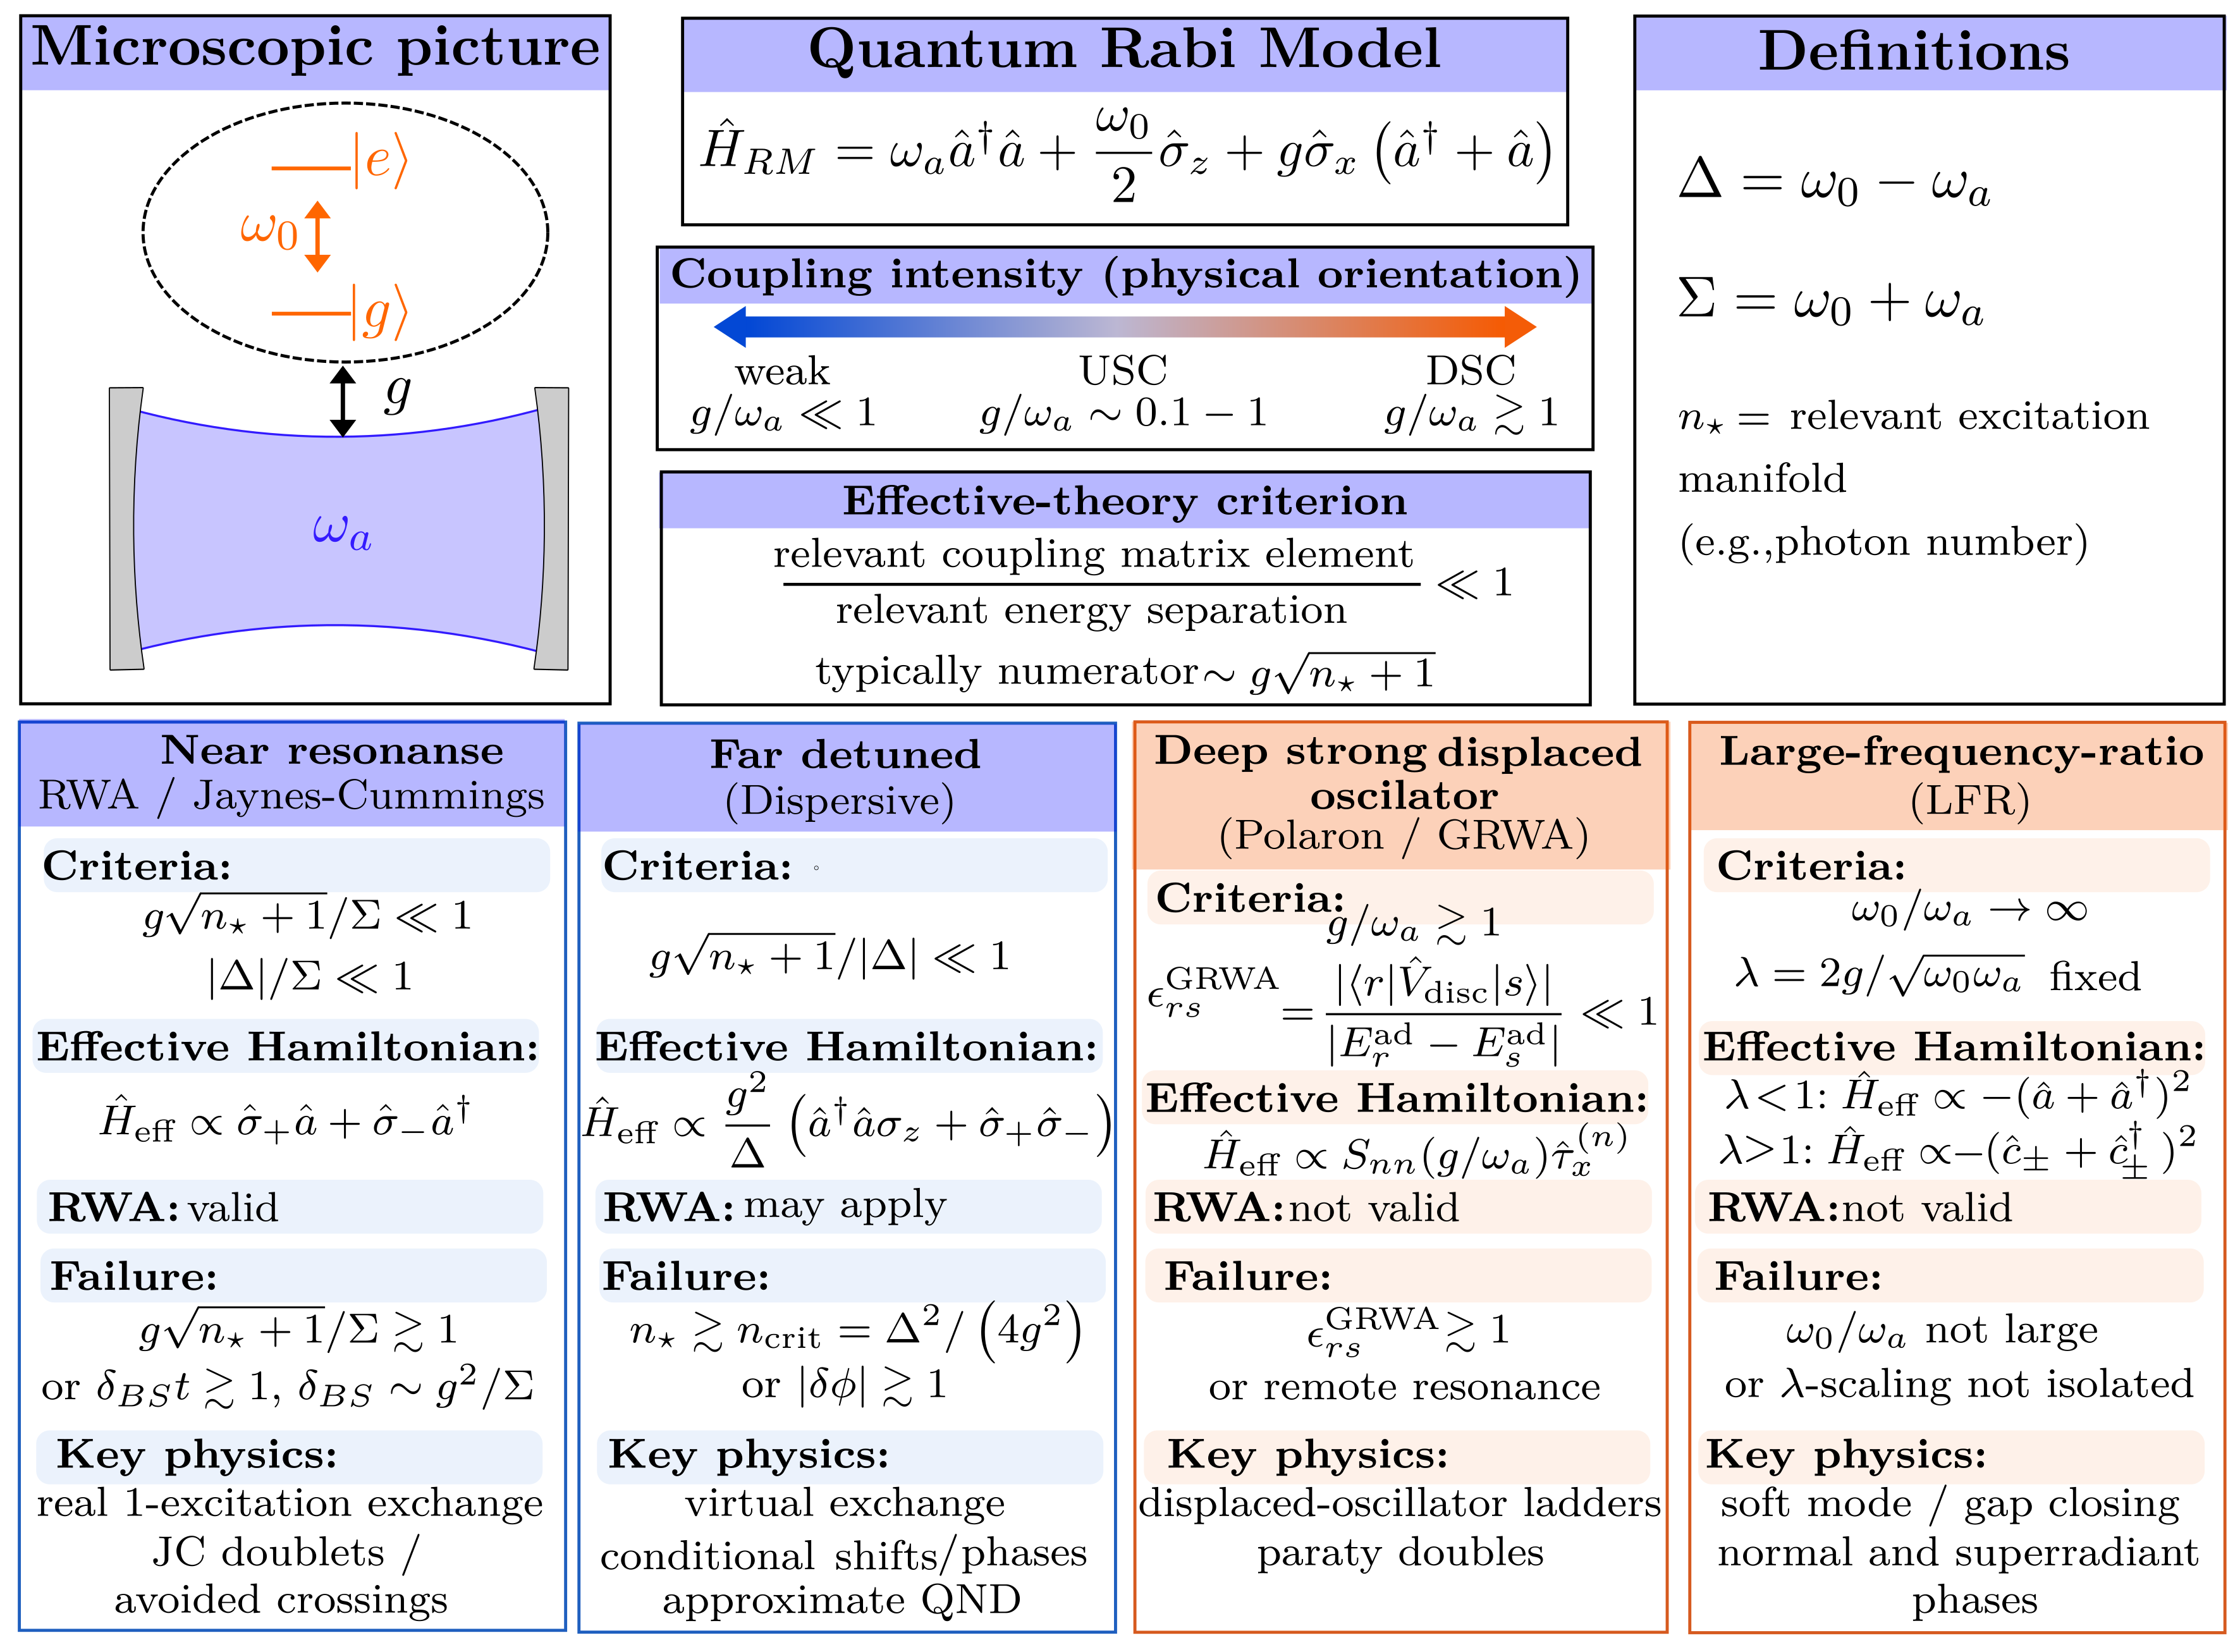

In [4]:
from hashlib import sha256
import shutil
from pathlib import Path
from IPython.display import Image, display

asset_pdf = Path("assets/manuscript/N08_MF1.pdf")
asset_png = Path("assets/manuscript/N08_MF1.png")
target_dir = Path("figures/manuscript")
target_dir.mkdir(parents=True, exist_ok=True)
target_pdf = target_dir / "N08_MF1.pdf"
target_png = target_dir / "N08_MF1.png"
shutil.copy2(asset_pdf, target_pdf)
shutil.copy2(asset_png, target_png)
assert sha256(asset_pdf.read_bytes()).hexdigest() == "458c41000f44a38209627d236ad9054c858623f42b5daa64bed350b8a5a9d6d1"
assert sha256(target_pdf.read_bytes()).hexdigest() == "458c41000f44a38209627d236ad9054c858623f42b5daa64bed350b8a5a9d6d1"
display(Image(filename=str(target_png), width=920))

**Manuscript Figure N08_MF1. One microscopic model, several effective theories.**
Each branch is organized by its own natural basis, retained structure, observables, and failure mode. The three-photon block is a local spectral reorganization rather than a universal fifth asymptotic branch.

## 4. RWA state dependence and short-time diagnostic

Writing $H_{\rm R}=H_{\rm JC}+V_{\rm cr}$, the same-frame fidelity satisfies

$$
F(t)=1-t^2\operatorname{Var}_{\psi_0}(V_{\rm cr})+O(t^3).
$$

For $|e\rangle|\alpha\rangle$, the coefficient is $g^2|\alpha|^2$. It vanishes for $|e,0\rangle$, even though the two evolutions can separate at later times. One state therefore cannot define a global RWA validity regime.

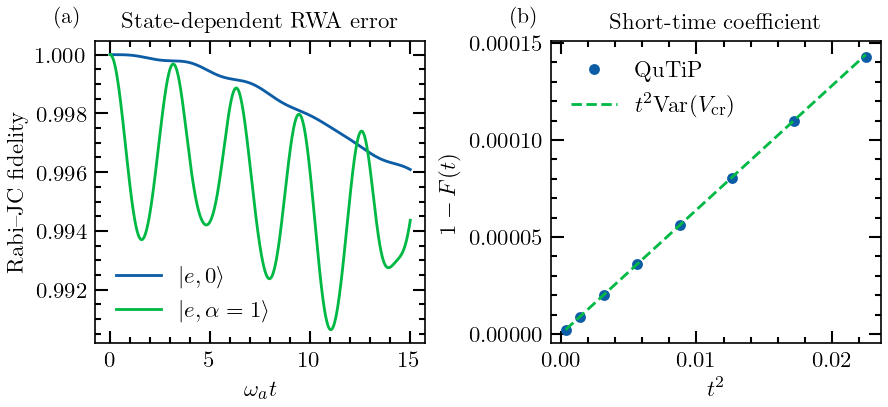

,quantity,value
0,variance_e0,0.000000
1,variance_e_coherent,0.006400
2,numeric_short_time_coefficient,0.006385
3,analytic_coefficient,0.006400


In [5]:
g_rwa = 0.08
alpha_rwa = 1.0
t_rwa = np.linspace(0.0, 15.0, 801)
H_rabi_rwa = rabi_hamiltonian(g_rwa)
H_jc_rwa = jc_hamiltonian(g_rwa)

ket_e = basis(2, 0)
psi_e0 = tensor(ket_e, basis(N_CAV, 0))
psi_ealpha = tensor(ket_e, coherent(N_CAV, alpha_rwa))

def fidelity_trajectory(psi0):
    exact = sesolve(H_rabi_rwa, psi0, t_rwa)
    approx = sesolve(H_jc_rwa, psi0, t_rwa)
    return np.array([abs(a_state.overlap(b_state)) ** 2 for a_state, b_state in zip(exact.states, approx.states)])

F_e0 = fidelity_trajectory(psi_e0)
F_ealpha = fidelity_trajectory(psi_ealpha)
Vcr = g_rwa * (sp * a.dag() + sm * a)

def variance(operator, state):
    mean = expect(operator, state)
    return float(np.real(expect(operator * operator, state) - mean * mean))

var_e0 = variance(Vcr, psi_e0)
var_ealpha = variance(Vcr, psi_ealpha)
short = (t_rwa > 0) & (t_rwa <= 0.15)
coefficient_numeric = float(np.median((1.0 - F_ealpha[short]) / t_rwa[short] ** 2))

rwa_data = pd.DataFrame({"t": t_rwa, "fidelity_e0": F_e0, "fidelity_e_coherent": F_ealpha})
save_table(rwa_data, "N08_D1")

fig, axes = plt.subplots(
    1, 2, figsize=(FIG_WIDTH_150MM, 2.70), constrained_layout=True
)
axes[0].plot(t_rwa, F_e0, label=r"$|e,0\rangle$")
axes[0].plot(t_rwa, F_ealpha, label=r"$|e,\alpha=1\rangle$")
axes[0].set(xlabel=r"$\omega_a t$", ylabel="Rabi--JC fidelity", title="State-dependent RWA error")
axes[0].legend(frameon=False)
axes[1].plot(t_rwa[short] ** 2, 1 - F_ealpha[short], "o", label="QuTiP")
axes[1].plot(t_rwa[short] ** 2, var_ealpha * t_rwa[short] ** 2, "--", label=r"$t^2\mathrm{Var}(V_{\rm cr})$")
axes[1].set(xlabel=r"$t^2$", ylabel=r"$1-F(t)$", title="Short-time coefficient")
axes[1].legend(frameon=False)
for label, ax in zip("ab", axes):
    ax.text(
        -0.12, 1.04, f"({label})", transform=ax.transAxes,
        fontsize=10.5, fontweight="bold", va="bottom", ha="left"
    )
save_figure(fig, "N08_F1")
plt.show()
plt.close(fig)

pd.DataFrame({
    "quantity": ["variance_e0", "variance_e_coherent", "numeric_short_time_coefficient", "analytic_coefficient"],
    "value": [var_e0, var_ealpha, coefficient_numeric, g_rwa**2 * abs(alpha_rwa)**2],
})

## 5. Dispersive Jaynes--Cummings benchmark

For the $n=0$ JC doublet, the exact centered eigenvalues are

$$
E_{\pm}=\pm\frac12\sqrt{\Delta^2+4g^2},
$$

while the second-order dispersive result for $\Delta>0$ is

$$
E_{\pm}^{(2)}=\pm\left(\frac{\Delta}{2}+\frac{g^2}{\Delta}\right).
$$

The first omitted spectral correction is fourth order for this block. This statement is local to the selected manifold; it is not a universal error law for every second-order calculation.

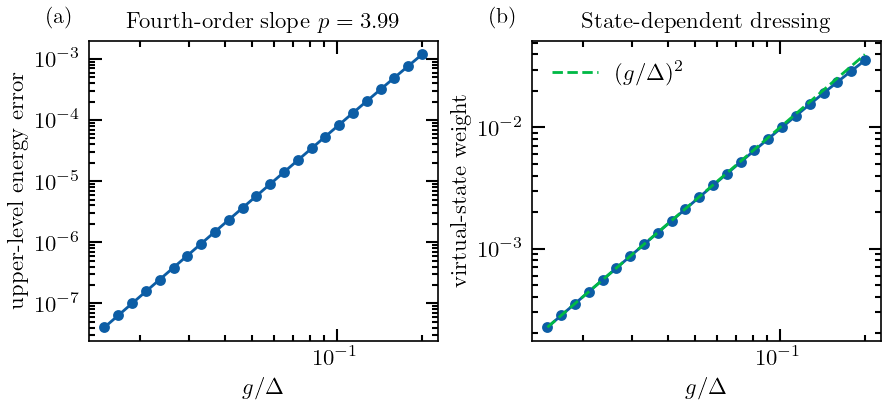

In [6]:
Delta_disp = 0.8
g_disp = np.geomspace(0.012, 0.16, 24)
error_disp = []
mixing_disp = []
for coupling in g_disp:
    block = qt.Qobj([[0.5 * Delta_disp, coupling], [coupling, -0.5 * Delta_disp]])
    exact_values, exact_states = block.eigenstates()
    upper_exact = float(exact_values[-1])
    upper_second = 0.5 * Delta_disp + coupling**2 / Delta_disp
    error_disp.append(abs(upper_exact - upper_second))
    mixing_disp.append(abs(basis(2, 1).overlap(exact_states[-1])) ** 2)

error_disp = np.asarray(error_disp)
mixing_disp = np.asarray(mixing_disp)
dispersive_slope = float(np.polyfit(np.log(g_disp[:16]), np.log(error_disp[:16]), 1)[0])

disp_data = pd.DataFrame({
    "g": g_disp,
    "g_over_Delta": g_disp / Delta_disp,
    "upper_energy_error": error_disp,
    "virtual_admixture": mixing_disp,
})
save_table(disp_data, "N08_D2")

fig, axes = plt.subplots(
    1, 2, figsize=(FIG_WIDTH_150MM, 2.70), constrained_layout=True
)
axes[0].loglog(g_disp / Delta_disp, error_disp, "o-")
axes[0].set(xlabel=r"$g/\Delta$", ylabel="upper-level energy error", title=fr"Fourth-order slope $p={dispersive_slope:.2f}$")
axes[1].loglog(g_disp / Delta_disp, mixing_disp, "o-")
axes[1].plot(g_disp / Delta_disp, (g_disp / Delta_disp) ** 2, "--", label=r"$(g/\Delta)^2$")
axes[1].set(xlabel=r"$g/\Delta$", ylabel="virtual-state weight", title="State-dependent dressing")
axes[1].legend(frameon=False)
for label, ax in zip("ab", axes):
    ax.text(
        -0.12, 1.04, f"({label})", transform=ax.transAxes,
        fontsize=10.5, fontweight="bold", va="bottom", ha="left"
    )
save_figure(fig, "N08_F2")
plt.show()
plt.close(fig)

### 5.1 What fourth order changes: spectrum, states, and observables

The second-order benchmark identifies the first omitted energy term but
does not show its physical consequences. The next figure separates four
tests. The adjacent upper-polariton transition reveals the
photon-number-dependent curvature generated at fourth order. Spectral
and mixing-angle remainders test the even- and odd-order series
independently. Finally, the physical $\sigma_z(t)$ signal shows why an
accurate diagonal generator with bare endpoints is still an incomplete
prediction.

For a selected doublet, write
$\eta_n=g\sqrt{n+1}/\Delta$. The exact centered upper energy and mixing
angle are
$$
E_{+,n}/\Delta=\tfrac12\sqrt{1+4\eta_n^2},
\qquad
\theta_n=\tfrac12\arctan(2\eta_n).
$$
The second- and fourth-order energies retain terms through
$\eta_n^2$ and $\eta_n^4$; the matching state transformations retain
$\theta_n$ through $\eta_n$ and $\eta_n^3$, respectively.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


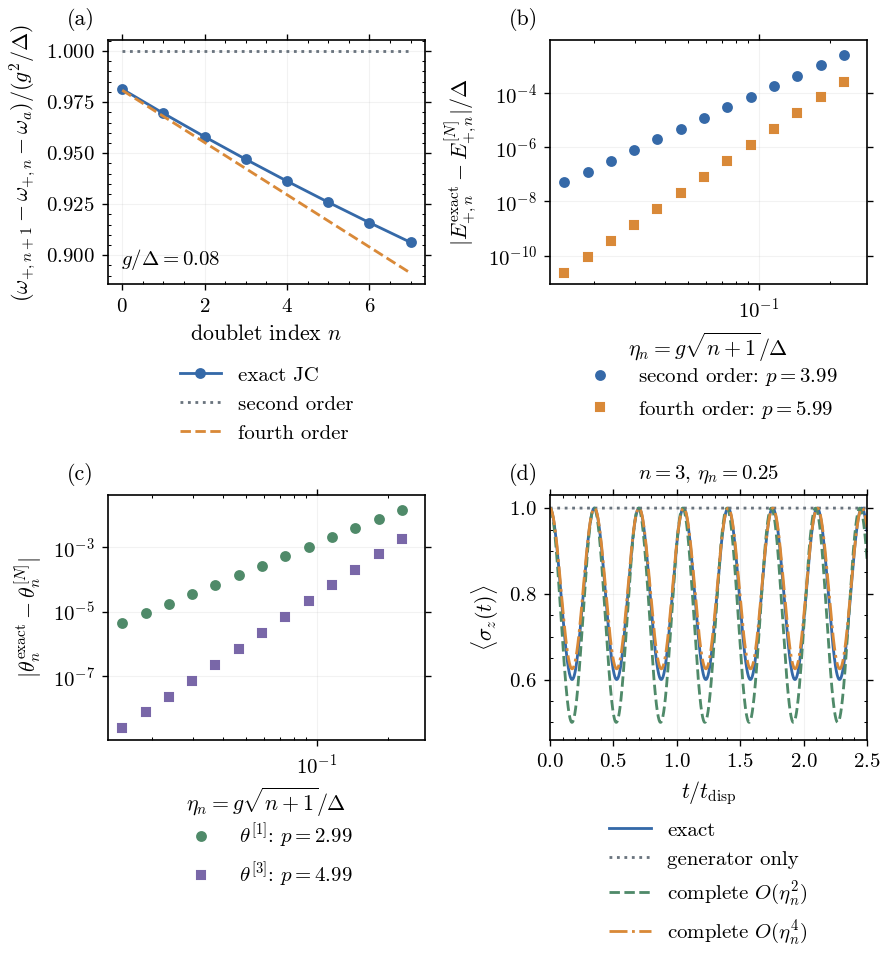

Energy-error exponents: 3.9918, 5.9897
Mixing-angle exponents: 2.9902, 4.9883


In [25]:
HIGH_ORDER_RC = {
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.family": "cmr10",
    "font.size": 10.5,
    "axes.labelsize": 10.5,
    "axes.titlesize": 10.5,
    "legend.fontsize": 10.0,
    "xtick.labelsize": 10.0,
    "ytick.labelsize": 10.0,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.35,
    "lines.markersize": 4.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
}

def high_order_panel_label(ax, label):
    ax.text(-0.13, 1.04, label, transform=ax.transAxes, fontsize=10.5,
            fontweight="bold", va="bottom", ha="left")

def high_order_finish_axis(ax):
    ax.tick_params(direction="out", length=2.8, width=0.65)
    ax.grid(alpha=0.16, linewidth=0.55)

# Exact formulas from the invariant JC block. Delta sets the energy unit.
Delta_high = 1.0
eta_grid = np.geomspace(0.015, 0.25, 100)
exact_upper = 0.5 * Delta_high * np.sqrt(1.0 + 4.0 * eta_grid**2)
upper_second = Delta_high * (0.5 + eta_grid**2)
upper_fourth = Delta_high * (0.5 + eta_grid**2 - eta_grid**4)
error_second = np.abs(exact_upper - upper_second) / Delta_high
error_fourth = np.abs(exact_upper - upper_fourth) / Delta_high

theta_exact = 0.5 * np.arctan(2.0 * eta_grid)
theta_first = eta_grid
theta_third = eta_grid - (4.0 / 3.0) * eta_grid**3
theta_error_first = np.abs(theta_exact - theta_first)
theta_error_third = np.abs(theta_exact - theta_third)

weak = eta_grid <= 0.10
energy_slope_second = float(np.polyfit(np.log(eta_grid[weak]), np.log(error_second[weak]), 1)[0])
energy_slope_fourth = float(np.polyfit(np.log(eta_grid[weak]), np.log(error_fourth[weak]), 1)[0])
angle_slope_first = float(np.polyfit(np.log(eta_grid[weak]), np.log(theta_error_first[weak]), 1)[0])
angle_slope_third = float(np.polyfit(np.log(eta_grid[weak]), np.log(theta_error_third[weak]), 1)[0])

# Photon-number-dependent upper-polariton cavity pull.
g_over_Delta_pull = 0.08
n_pull = np.arange(0, 8)
omega_n = np.sqrt(1.0 + 4.0 * g_over_Delta_pull**2 * (n_pull + 1.0))
omega_np1 = np.sqrt(1.0 + 4.0 * g_over_Delta_pull**2 * (n_pull + 2.0))
pull_exact = 0.5 * (omega_np1 - omega_n) / g_over_Delta_pull**2
pull_second = np.ones_like(pull_exact)
pull_fourth = 1.0 - g_over_Delta_pull**2 * (2.0 * n_pull + 3.0)

# Physical sigma_z dynamics for one moderately dispersive manifold.
n_dyn = 3
eta_dyn = 0.25
g_over_Delta_dyn = eta_dyn / np.sqrt(n_dyn + 1.0)
t_disp = 1.0 / eta_dyn**2
t_over_tdisp = np.linspace(0.0, 2.5, 1601)
t_dyn = t_over_tdisp * t_disp
omega_exact_dyn = np.sqrt(1.0 + 4.0 * eta_dyn**2)
omega_second_dyn = 1.0 + 2.0 * eta_dyn**2
omega_fourth_dyn = 1.0 + 2.0 * eta_dyn**2 - 2.0 * eta_dyn**4
amplitude_exact = 8.0 * eta_dyn**2 / (1.0 + 4.0 * eta_dyn**2)
amplitude_second = 8.0 * eta_dyn**2
amplitude_fourth = 8.0 * eta_dyn**2 - 32.0 * eta_dyn**4
sigmaz_exact = 1.0 - amplitude_exact * np.sin(0.5 * omega_exact_dyn * t_dyn)**2
sigmaz_second = 1.0 - amplitude_second * np.sin(0.5 * omega_second_dyn * t_dyn)**2
sigmaz_fourth = 1.0 - amplitude_fourth * np.sin(0.5 * omega_fourth_dyn * t_dyn)**2
sigmaz_generator_only = np.ones_like(t_dyn)

save_table(pd.DataFrame({
    "eta_n": eta_grid,
    "exact_upper_over_Delta": exact_upper / Delta_high,
    "second_order_upper_over_Delta": upper_second / Delta_high,
    "fourth_order_upper_over_Delta": upper_fourth / Delta_high,
    "energy_error_second": error_second,
    "energy_error_fourth": error_fourth,
    "theta_exact": theta_exact,
    "theta_first_order": theta_first,
    "theta_third_order": theta_third,
    "theta_error_first": theta_error_first,
    "theta_error_third": theta_error_third,
}), "N08_D10_high_order_jc_spectrum")
save_table(pd.DataFrame({
    "n": n_pull,
    "eta_n": g_over_Delta_pull * np.sqrt(n_pull + 1.0),
    "normalized_pull_exact": pull_exact,
    "normalized_pull_second": pull_second,
    "normalized_pull_fourth": pull_fourth,
}), "N08_D11_high_order_jc_nonlinearity")
save_table(pd.DataFrame({
    "t_over_tdisp": t_over_tdisp,
    "sigmaz_exact": sigmaz_exact,
    "sigmaz_generator_only": sigmaz_generator_only,
    "sigmaz_complete_second": sigmaz_second,
    "sigmaz_complete_fourth": sigmaz_fourth,
}), "N08_D12_high_order_jc_dynamics")

blue = "#3569A8"
orange = "#D98938"
green = "#4F8A69"
purple = "#7967A8"
gray = "#69737D"

with plt.style.context(["science", "no-latex"]), plt.rc_context(HIGH_ORDER_RC):
    fig, axes = plt.subplots(
        2, 2, figsize=(FIG_WIDTH_150MM, 5.10), constrained_layout=True
    )
    ax_a, ax_b, ax_c, ax_d = axes.flat

    ax_a.plot(n_pull, pull_exact, "o-", color=blue, label="exact JC")
    ax_a.plot(n_pull, pull_second, color=gray, linestyle=":", label="second order")
    ax_a.plot(n_pull, pull_fourth, color=orange, linestyle="--", label="fourth order")
    ax_a.set(xlabel=r"doublet index $n$", ylabel=r"$(\omega_{+,n+1}-\omega_{+,n}-\omega_a)/(g^2/\Delta)$")
    ax_a.text(0.04, 0.08, r"$g/\Delta=0.08$", transform=ax_a.transAxes, fontsize=10.0)
    ax_a.legend(frameon=False, loc="upper right")
    high_order_finish_axis(ax_a)
    high_order_panel_label(ax_a, "(a)")

    ax_b.loglog(eta_grid, error_second, "o", markevery=8, color=blue,
                label=rf"second order: $p={energy_slope_second:.2f}$")
    ax_b.loglog(eta_grid, error_fourth, "s", markevery=8, color=orange,
                label=rf"fourth order: $p={energy_slope_fourth:.2f}$")
    ax_b.set(xlabel=r"$\eta_n=g\sqrt{n+1}/\Delta$", ylabel=r"$|E_{+,n}^{\rm exact}-E_{+,n}^{[N]}|/\Delta$")
    ax_b.legend(frameon=False, loc="lower right")
    high_order_finish_axis(ax_b)
    high_order_panel_label(ax_b, "(b)")

    ax_c.loglog(eta_grid, theta_error_first, "o", markevery=8, color=green,
                label=rf"$\theta^{{[1]}}$: $p={angle_slope_first:.2f}$")
    ax_c.loglog(eta_grid, theta_error_third, "s", markevery=8, color=purple,
                label=rf"$\theta^{{[3]}}$: $p={angle_slope_third:.2f}$")
    ax_c.set(xlabel=r"$\eta_n=g\sqrt{n+1}/\Delta$", ylabel=r"$|\theta_n^{\rm exact}-\theta_n^{[N]}|$")
    ax_c.legend(frameon=False, loc="lower right")
    high_order_finish_axis(ax_c)
    high_order_panel_label(ax_c, "(c)")

    ax_d.plot(t_over_tdisp, sigmaz_exact, color=blue, label="exact")
    ax_d.plot(t_over_tdisp, sigmaz_generator_only, color=gray, linestyle=":",
              label="generator only")
    ax_d.plot(t_over_tdisp, sigmaz_second, color=green, linestyle="--",
              label=r"complete $O(\eta_n^2)$")
    ax_d.plot(t_over_tdisp, sigmaz_fourth, color=orange, linestyle="-.",
              label=r"complete $O(\eta_n^4)$")
    ax_d.set(xlabel=r"$t/t_{\rm disp}$", ylabel=r"$\langle\sigma_z(t)\rangle$",
             xlim=(0.0, 2.5), ylim=(0.46, 1.03))
    ax_d.set_title(
    rf"$n={n_dyn}$, $\eta_n={eta_dyn:.2f}$",
    fontsize=10.0,
    pad=8,)
    ax_d.legend(frameon=False, loc="lower center", ncol=2, columnspacing=0.9)
    high_order_finish_axis(ax_d)
    high_order_panel_label(ax_d, "(d)")

    # Mais altura para acomodar as legendas; largura de 150 mm.
    fig.set_size_inches(FIG_WIDTH_150MM, 6.40)

    for ax in axes.flat:
        ax.legend(
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.30),
            ncol=1,
            borderaxespad=0.0,
        )

    save_figure(fig, "N08_F4")
    plt.show()
    plt.close(fig)

print(f"Energy-error exponents: {energy_slope_second:.4f}, {energy_slope_fourth:.4f}")
print(f"Mixing-angle exponents: {angle_slope_first:.4f}, {angle_slope_third:.4f}")


**Notebook Figure N08_F4. Higher-order dispersive physics in one exact JC block.**
The nonlinear upper-polariton pull is flat at second order and acquires
the occupation-dependent fourth-order curvature. The spectral
remainders scale as $\eta_n^4$ and $\eta_n^6$, whereas the omitted
mixing-angle terms scale as $\eta_n^3$ and $\eta_n^5$. In the physical
dynamics, the diagonal generator with bare endpoints misses the virtual
oscillation completely. Consistent reconstruction restores the signal,
and the fourth-order prediction reduces both amplitude and phase error.


## 6. Spectral reorganization and low-energy subspaces

At weak resonant coupling, the lowest states inherit the Jaynes--Cummings excitation-manifold organization. At deep-strong coupling, the natural zeroth-order states are

$$
|\pm_x,n_\pm\rangle=|\pm_x\rangle D(\mp g/\omega_a)|n\rangle.
$$

Subspace fidelity avoids an arbitrary comparison between individual eigenvectors inside degenerate or nearly degenerate manifolds:

$$
F_{\rm sub}=\frac1d\operatorname{Tr}(P_{\rm exact}P_{\rm ref}).
$$

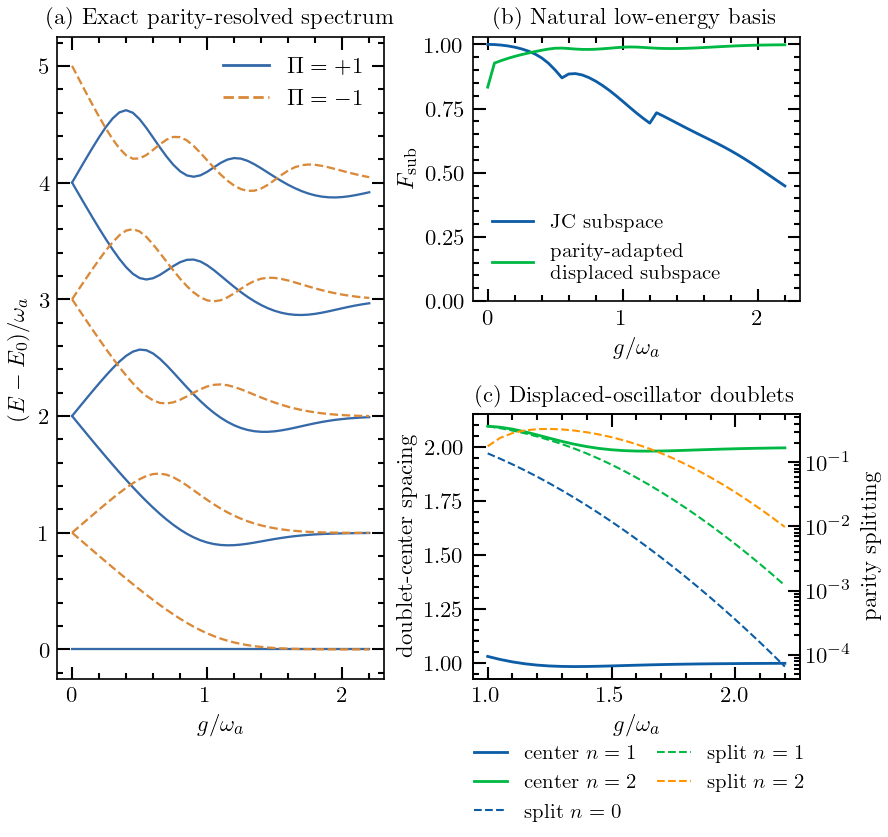

In [23]:
from scipy.optimize import linear_sum_assignment

g_scan = np.linspace(0.0, 2.2, 45)
n_levels = 10
subspace_dimension = 6
overlap_floor = 0.50
spectrum = np.empty((len(g_scan), n_levels))
parity_values = np.empty_like(spectrum)
fidelity_jc = np.empty(len(g_scan))
fidelity_displaced = np.empty(len(g_scan))
tracked_energy = np.full((len(g_scan), 3, 2), np.nan)
tracked_overlap = np.full_like(tracked_energy, np.nan)

ket_plus_x = (basis(2, 0) + basis(2, 1)).unit()
ket_minus_x = (basis(2, 0) - basis(2, 1)).unit()
identity_full = tensor(I_Q, I_C)

def orthonormal_projector(states, template):
    matrix = np.column_stack([state.full().ravel() for state in states])
    q, _ = np.linalg.qr(matrix)
    vectors = [qt.Qobj(q[:, k].reshape((-1, 1)), dims=states[0].dims) for k in range(q.shape[1])]
    return sum((state.proj() for state in vectors), 0 * template)

for row, coupling in enumerate(g_scan):
    H = rabi_hamiltonian(coupling)
    evals, evecs = H.eigenstates()
    evals = np.asarray(evals, dtype=float)
    all_parities = np.array([np.real(expect(parity, state)) for state in evecs])
    spectrum[row] = evals[:n_levels] - evals[0]
    parity_values[row] = all_parities[:n_levels]
    P_exact = sum((state.proj() for state in evecs[:subspace_dimension]), 0 * H)

    H_jc = jc_hamiltonian(coupling)
    _, jc_states = H_jc.eigenstates()
    P_jc = sum((state.proj() for state in jc_states[:subspace_dimension]), 0 * H)

    eta = coupling / OMEGA_A
    targets_by_parity = {+1: [], -1: []}
    for oscillator_index in range(3):
        raw = tensor(
            ket_plus_x,
            displace(N_CAV, -eta) * basis(N_CAV, oscillator_index),
        )
        for parity_sign in (+1, -1):
            projected = 0.5 * (identity_full + parity_sign * parity) * raw
            targets_by_parity[parity_sign].append(projected.unit())

    displaced_states = targets_by_parity[+1] + targets_by_parity[-1]
    P_displaced = orthonormal_projector(displaced_states, H)
    fidelity_jc[row] = np.real((P_exact * P_jc).tr()) / subspace_dimension
    fidelity_displaced[row] = np.real((P_exact * P_displaced).tr()) / subspace_dimension

    for parity_column, parity_sign in enumerate((+1, -1)):
        candidates = [
            index for index, value in enumerate(all_parities[:24])
            if parity_sign * value > 0.5
        ]
        overlaps = np.array([
            [abs(target.overlap(evecs[index])) ** 2 for index in candidates]
            for target in targets_by_parity[parity_sign]
        ])
        target_rows, candidate_columns = linear_sum_assignment(-overlaps)
        for target_index, candidate_column in zip(target_rows, candidate_columns):
            weight = overlaps[target_index, candidate_column]
            if weight >= overlap_floor:
                state_index = candidates[candidate_column]
                tracked_energy[row, target_index, parity_column] = evals[state_index]
                tracked_overlap[row, target_index, parity_column] = weight

pair_centers = np.nanmean(tracked_energy, axis=2)
pair_splittings = np.abs(tracked_energy[:, :, 0] - tracked_energy[:, :, 1])
center_spacings = pair_centers - pair_centers[:, [0]]

spectral_rows = []
for row, coupling in enumerate(g_scan):
    for level in range(n_levels):
        spectral_rows.append((coupling, level, spectrum[row, level], parity_values[row, level]))
save_table(pd.DataFrame(spectral_rows, columns=["g_over_omega", "level", "excitation_energy", "parity"]), "N08_D3")
save_table(pd.DataFrame({"g_over_omega": g_scan, "F_sub_JC": fidelity_jc, "F_sub_displaced": fidelity_displaced}), "N08_D4")

spectrum_plus = np.full((len(g_scan), n_levels // 2), np.nan)
spectrum_minus = np.full((len(g_scan), n_levels // 2), np.nan)
for row in range(len(g_scan)):
    plus_values = np.sort(spectrum[row, parity_values[row] > 0])
    minus_values = np.sort(spectrum[row, parity_values[row] < 0])
    spectrum_plus[row, :len(plus_values)] = plus_values
    spectrum_minus[row, :len(minus_values)] = minus_values

fig = plt.figure(figsize=(FIG_WIDTH_150MM, 4.95), constrained_layout=True)
gs = fig.add_gridspec(2, 2)
ax_a = fig.add_subplot(gs[:, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 1])

for branch in range(n_levels // 2):
    ax_a.plot(g_scan, spectrum_plus[:, branch], color="#3569a8", lw=1.1)
    ax_a.plot(g_scan, spectrum_minus[:, branch], color="#d98938", lw=1.1, ls="--")
ax_a.set(xlabel=r"$g/\omega_a$", ylabel=r"$(E-E_0)/\omega_a$", title="(a) Exact parity-resolved spectrum")
ax_a.plot([], [], color="#3569a8", label=r"$\Pi=+1$")
ax_a.plot([], [], color="#d98938", ls="--", label=r"$\Pi=-1$")
ax_a.legend(frameon=False)

ax_b.plot(g_scan, fidelity_jc, label="JC subspace")
ax_b.plot(g_scan, fidelity_displaced, label="parity-adapted\ndisplaced subspace")
ax_b.set(xlabel=r"$g/\omega_a$", ylabel=r"$F_{\rm sub}$", ylim=(0, 1.03), title="(b) Natural low-energy basis")
ax_b.legend(frameon=False, fontsize=10.0)

deep = g_scan >= 1.0
for manifold in (1, 2):
    ax_c.plot(g_scan[deep], center_spacings[deep, manifold], label=fr"center $n={manifold}$")
ax_c.set(xlabel=r"$g/\omega_a$", ylabel="doublet-center spacing", title="(c) Displaced-oscillator doublets")
ax_split = ax_c.twinx()
for manifold in range(3):
    ax_split.semilogy(g_scan[deep], pair_splittings[deep, manifold], ls="--", lw=1.0, label=fr"split $n={manifold}$")
ax_split.set_ylabel("parity splitting")
handles = ax_c.get_lines() + ax_split.get_lines()
fig.legend(
    handles,
    [line.get_label() for line in handles],
    frameon=False,
    fontsize=10.0,
    ncol=2,
    loc="lower center",
    bbox_to_anchor=(0.72, -0.13),
    columnspacing=1.0,
    handlelength=1.6,
)

save_figure(fig, "N08_MF2", manuscript=True)
plt.show()
plt.close(fig)

pd.DataFrame({
    "g_over_omega": g_scan,
    **{f"center_{k}": pair_centers[:, k] for k in range(3)},
    **{f"splitting_{k}": pair_splittings[:, k] for k in range(3)},
    **{f"min_overlap_{k}": np.nanmin(tracked_overlap[:, k, :], axis=1) for k in range(3)},
}).to_csv(DATA / "N08_D5.csv", index=False)

**Manuscript Figure N08_MF2. Spectral reorganization of the resonant quantum Rabi model. The displaced basis is parity adapted, and the deep-coupling doublets are assigned by one-to-one overlap matching rather than by adjacent energy order.**
The exact spectrum evolves from the weak-coupling excitation-manifold organization toward low-energy pairs. Projector overlaps identify which reference subspace is economical without choosing an arbitrary basis inside a nearly degenerate manifold. The lowest pair splittings decrease in the displaced regime.

## 7. Bare, displaced, and detector-defined excitations

A stationary interacting ground state can have nonzero $\langle a^\dagger a\rangle$. This is not a stationary output photon flux. We compare:

$$
n_{\rm bare}=\langle a^\dagger a\rangle,
\qquad
n_{\rm disp}=\langle b^\dagger b\rangle,
\qquad
b=a+(g/\omega_a)\sigma_x,
$$

and the detector-defined signal of the first excited state, $\langle1|X^-X^+|1\rangle$, with $X=a+a^\dagger$ and $X^+$ constructed in the exact interacting eigenbasis. By construction, a zero-temperature detector sees no downward transition out of the exact ground state.

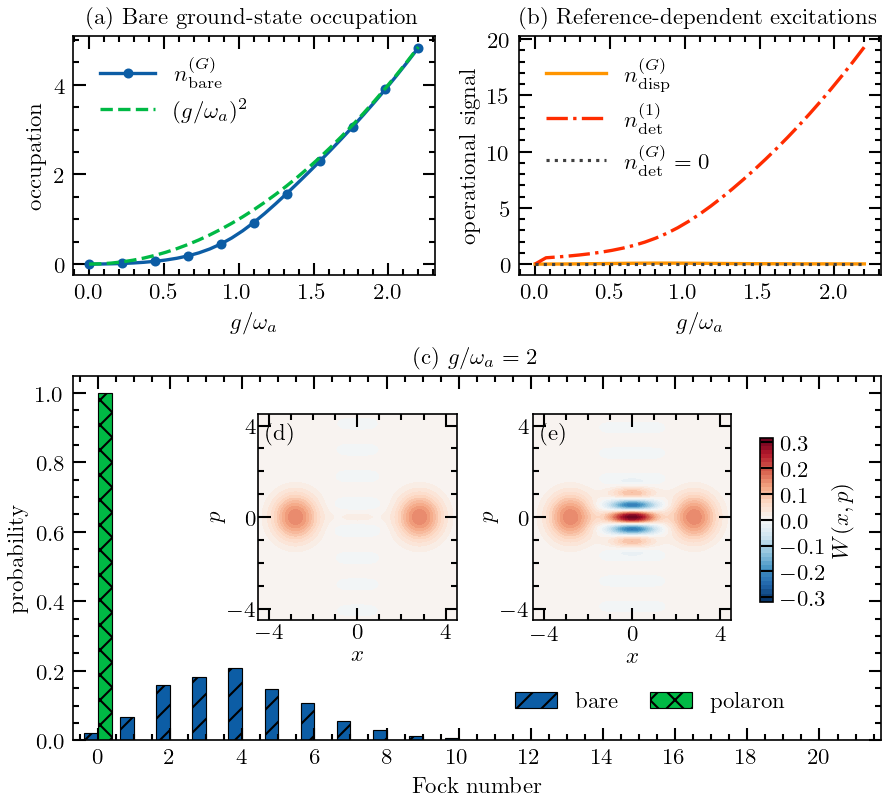

In [9]:
g_obs = np.linspace(0.0, 2.2, 31)
n_bare = []
n_displaced = []
n_detector_first = []

X = a + a.dag()
for coupling in g_obs:
    H = rabi_hamiltonian(coupling)
    evals, states = H.eigenstates()
    ground, first = states[0], states[1]
    b_displaced = a + (coupling / OMEGA_A) * sx
    n_bare.append(expect(n, ground))
    n_displaced.append(expect(b_displaced.dag() * b_displaced, ground))
    n_detector_first.append(abs(ground.overlap(X * first)) ** 2)

n_bare = np.real(np.asarray(n_bare))
n_displaced = np.real(np.asarray(n_displaced))
n_detector_first = np.real(np.asarray(n_detector_first))

g_star = 2.0
H_star = rabi_hamiltonian(g_star)
evals_star, states_star = H_star.eigenstates()
ground_star = states_star[0]
rho_full_star = ket2dm(ground_star)
rho_osc = rho_full_star.ptrace(1)

eta_star = g_star / OMEGA_A
Ppx = ket_plus_x.proj()
Pmx = ket_minus_x.proj()
U_polaron = tensor(Ppx, displace(N_CAV, -eta_star)) + tensor(Pmx, displace(N_CAV, eta_star))
ground_polaron = U_polaron.dag() * ground_star
rho_polaron = ket2dm(ground_polaron).ptrace(1)

P_g = tensor(basis(2, 1).proj(), I_C)
rho_conditioned = (P_g * rho_full_star * P_g).ptrace(1)
rho_conditioned = rho_conditioned / rho_conditioned.tr()

fock = np.arange(22)
P_fock_bare = np.real(np.diag(rho_osc.full()))[:len(fock)]
P_fock_polaron = np.real(np.diag(rho_polaron.full()))[:len(fock)]
xvec = np.linspace(-4.5, 4.5, 101)
W_unconditional = wigner(rho_osc, xvec, xvec)
W_conditioned = wigner(rho_conditioned, xvec, xvec)
vmax = max(np.max(np.abs(W_unconditional)), np.max(np.abs(W_conditioned)))

save_table(pd.DataFrame({
    "g_over_omega": g_obs,
    "n_bare_ground": n_bare,
    "n_displaced_ground": n_displaced,
    "detector_signal_first_excited": n_detector_first,
    "detector_signal_ground": np.zeros_like(g_obs),
}), "N08_D6")
save_table(pd.DataFrame({"n": fock, "P_bare": P_fock_bare, "P_polaron": P_fock_polaron}), "N08_D7")

# Compact manuscript layout at 150 mm width:
# (a) and (b) share the top row, while (c) spans the full lower row.
# The Wigner functions (d) and (e) are shown as insets of panel (c).
FIG_HEIGHT_MF3 = 5.35
fig = plt.figure(figsize=(FIG_WIDTH_150MM, FIG_HEIGHT_MF3), constrained_layout=True)
gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[0.95, 1.45],
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# Keep every textual element at 11 pt.
for ax in (ax_a, ax_b, ax_c):
    ax.tick_params(axis="both", labelsize=11)

# (a) Curves remain colored, but also use distinct line/marker patterns
# so they remain distinguishable in grayscale.
ax_a.plot(
    g_obs,
    n_bare,
    color="C0",
    linestyle="-",
    marker="o",
    markevery=3,
    markersize=3.8,
    linewidth=1.6,
    label=r"$n_{\rm bare}^{(G)}$",
)
ax_a.plot(
    g_obs,
    g_obs**2,
    color="C1",
    linestyle="--",
    linewidth=1.6,
    label=r"$(g/\omega_a)^2$",
)
ax_a.set(
    xlabel=r"$g/\omega_a$",
    ylabel="occupation",
    title="(a) Bare ground-state occupation",
)
ax_a.xaxis.label.set_size(11)
ax_a.yaxis.label.set_size(11)
ax_a.title.set_size(11)
ax_a.legend(
    frameon=False,
    fontsize=11,
    handlelength=2.4,
    loc="upper left",
    bbox_to_anchor=(0.02, 1.00),
)

# (b) Each curve has a different linestyle and marker in addition to color.
ax_b.plot(
    g_obs,
    n_displaced,
    color="C2",
    linestyle="-",
    linewidth=1.6,
    label=r"$n_{\rm disp}^{(G)}$",
)
ax_b.plot(
    g_obs,
    n_detector_first,
    color="C3",
    linestyle="-.",
    linewidth=1.6,
    label=r"$n_{\rm det}^{(1)}$",
)
ax_b.plot(
    g_obs,
    np.zeros_like(g_obs),
    color="0.25",
    linestyle=":",
    linewidth=1.5,
    label=r"$n_{\rm det}^{(G)}=0$",
)
ax_b.set(
    xlabel=r"$g/\omega_a$",
    ylabel="operational signal",
    title="(b) Reference-dependent excitations",
)
ax_b.xaxis.label.set_size(11)
ax_b.yaxis.label.set_size(11)
ax_b.title.set_size(11)
ax_b.legend(
    frameon=False,
    fontsize=11,
    handlelength=2.6,
    loc="upper left",
    bbox_to_anchor=(0.02, 1.00),
)

# (c) Main number-distribution panel. Different hatches keep the two
# data sets separable in black and white while preserving their colors.
ax_c.bar(
    fock - 0.19,
    P_fock_bare,
    width=0.38,
    color="C0",
    edgecolor="black",
    linewidth=0.55,
    hatch="//",
    label="bare",
)
ax_c.bar(
    fock + 0.19,
    P_fock_polaron,
    width=0.38,
    color="C1",
    edgecolor="black",
    linewidth=0.55,
    hatch="xx",
    label="polaron",
)
ax_c.set(
    xlabel="Fock number",
    ylabel="probability",
    title=r"(c) $g/\omega_a=2$",
)
ax_c.set_xlim(-0.7, len(fock) - 0.3)
ax_c.set_xticks(np.arange(0, len(fock), 2))
ax_c.xaxis.label.set_size(11)
ax_c.yaxis.label.set_size(11)
ax_c.title.set_size(11)
# -----------------------------------------------------------------------------
# PANEL (c) INTERNAL LAYOUT CONTROLS
# All coordinates below are fractions of ax_c: 0 = left/bottom, 1 = right/top.
# You can move/resize the legend, Wigner insets, and colorbar by changing only
# these numbers, without touching the plotting commands below.
# -----------------------------------------------------------------------------

# Legend of panel (c).
LEGEND_C_X = 0.715
LEGEND_C_Y = 0.105
LEGEND_C_LOC = "center"

# Inset (d): x-position, y-position, width, height.
INSET_D_X = 0.23
INSET_D_Y = 0.33
INSET_D_W = 0.245
INSET_D_H = 0.565

# Inset (e): x-position, y-position, width, height.
INSET_E_X = 0.57
INSET_E_Y = 0.33
INSET_E_W = 0.245
INSET_E_H = 0.565

# Shared horizontal colorbar: x-position, y-position, width, height.
COLORBAR_X = 0.85
COLORBAR_Y = 0.38
COLORBAR_W = 0.016
COLORBAR_H = 0.45


# The panel-(c) legend sits below the two Wigner insets.
ax_c.legend(
    frameon=False,
    fontsize=11,
    ncol=2,
    handlelength=1.8,
    loc=LEGEND_C_LOC,
    bbox_to_anchor=(LEGEND_C_X, LEGEND_C_Y),
    bbox_transform=ax_c.transAxes,
    columnspacing=1.4,
)

# (d) and (e) are inset Wigner functions inside panel (c).
# The default values make them substantially larger and start them only after
# the visible Fock-weight region, using most of the otherwise empty right side.
ax_d = ax_c.inset_axes(
    [INSET_D_X, INSET_D_Y, INSET_D_W, INSET_D_H],
    zorder=5,
)
ax_e = ax_c.inset_axes(
    [INSET_E_X, INSET_E_Y, INSET_E_W, INSET_E_H],
    zorder=5,
)

# Explicit symmetric levels make the colorbar occupy its full length.
wigner_levels = np.linspace(-vmax, vmax, 41)

im0 = ax_d.contourf(
    xvec,
    xvec,
    W_unconditional,
    levels=wigner_levels,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
ax_d.set_xlabel(r"$x$", fontsize=11, labelpad=1)
ax_d.set_ylabel(r"$p$", fontsize=11, labelpad=1)
ax_d.tick_params(axis="both", labelsize=11, pad=1)
ax_d.set_xticks([-4, 0, 4])
ax_d.set_yticks([-4, 0, 4])
ax_d.text(
    0.04,
    0.96,
    "(d)",
    transform=ax_d.transAxes,
    fontsize=11,
    ha="left",
    va="top",
)

im1 = ax_e.contourf(
    xvec,
    xvec,
    W_conditioned,
    levels=wigner_levels,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
ax_e.set_xlabel(r"$x$", fontsize=11, labelpad=1)
ax_e.set_ylabel(r"$p$", fontsize=11, labelpad=1)
ax_e.tick_params(axis="both", labelsize=11, pad=2)
ax_e.set_xticks([-4, 0, 4])
ax_e.set_yticks([-4, 0, 4])
ax_e.text(
    0.04,
    0.96,
    "(e)",
    transform=ax_e.transAxes,
    fontsize=11,
    ha="left",
    va="top",
)

# Compact shared horizontal color scale above the Wigner insets.
cax = ax_c.inset_axes(
    [COLORBAR_X, COLORBAR_Y, COLORBAR_W, COLORBAR_H],
    zorder=5,
)
cbar = fig.colorbar(im1, cax=cax, orientation="vertical")

# Symmetric one-decimal tick labels; zero is omitted to keep the compact scale
# uncluttered. Because the contour levels are explicitly symmetric, no blank
# segment is left inside the colorbar.
wigner_ticks = np.array([-0.3, -0.2,0.0,-0.1, 0.1, 0.2, 0.3])
cbar.set_ticks(wigner_ticks)
cbar.set_label(r"$W(x,p)$", fontsize=11, labelpad=2)

save_figure(fig, "N08_MF3", manuscript=True)
plt.show()
plt.close(fig)


**Manuscript Figure N08_MF3. Bare, displaced, and detector-defined excitations.**
The exact ground state develops a large bare oscillator occupation while remaining close to the vacuum of the qubit-conditioned displaced wells. A detector defined in the interacting eigenbasis has no downward transition from the stationary ground state. Bare and polaron-frame number distributions, unconditional oscillator phase space, and qubit-conditioned phase space describe different operational questions.

## 8. Singular critical scaling versus a finite-frequency crossover

The single-qubit quantum Rabi model has a normal-to-superradiant quantum phase transition only in the singular limit

$$
\omega_0/\omega_a\rightarrow\infty,
\qquad
\lambda=\frac{2g}{\sqrt{\omega_0\omega_a}}
\quad\text{fixed}.
$$

The leading gaps are

$$
\varepsilon_{\rm np}=\omega_a\sqrt{1-\lambda^2},\quad \lambda<1,
$$

and

$$
\varepsilon_{\rm sp}=\omega_a\sqrt{1-\lambda^{-4}},\quad \lambda>1.
$$

At any finite ratio, exact parity is retained and the spectrum shows a crossover with finite-frequency scaling. A numerical gap minimum at finite ratio must not be called spontaneous symmetry breaking without this limiting qualification.

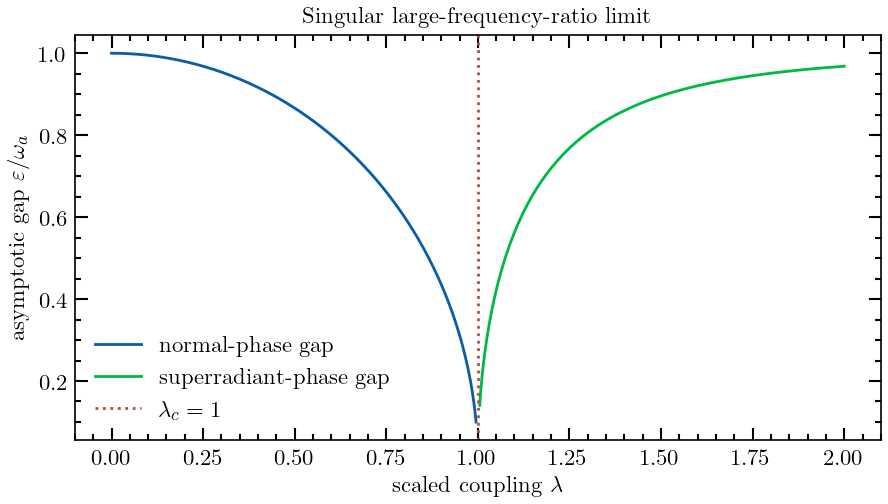

In [10]:
lambda_left = np.linspace(0.0, 0.995, 300)
lambda_right = np.linspace(1.005, 2.0, 300)
gap_normal = np.sqrt(1.0 - lambda_left**2)
gap_super = np.sqrt(1.0 - lambda_right**-4)
critical_data = pd.DataFrame({
    "lambda_normal": np.pad(lambda_left, (0, len(lambda_right) - len(lambda_left)), constant_values=np.nan),
    "gap_normal": np.pad(gap_normal, (0, len(lambda_right) - len(gap_normal)), constant_values=np.nan),
    "lambda_superradiant": lambda_right,
    "gap_superradiant": gap_super,
})
save_table(critical_data, "N08_D8")

fig, ax = plt.subplots(
    figsize=(FIG_WIDTH_150MM, 3.35), constrained_layout=True
)
ax.plot(lambda_left, gap_normal, label="normal-phase gap")
ax.plot(lambda_right, gap_super, label="superradiant-phase gap")
ax.axvline(1.0, color="#b94b4b", ls=":", label=r"$\lambda_c=1$")
ax.set(xlabel=r"scaled coupling $\lambda$", ylabel=r"asymptotic gap $\varepsilon/\omega_a$", title="Singular large-frequency-ratio limit")
ax.legend(frameon=False)
save_figure(fig, "N08_F3")
plt.show()
plt.close(fig)

## 9. Selected multiphoton blocks and relation to N05

A multiphoton resonance is local in spectrum. Near $\omega_0\simeq3\omega_a$, the same-parity states $|e,0\rangle$ and $|g,3\rangle$ must be retained together. The diagonal displacement is second order while the off-diagonal gap is third order:

$$
\omega_a^{\rm res}-\omega_0/3=O(g^2),
\qquad
\Delta_{\rm gap}=O(g^3).
$$

N05 derives and validates this block in full. N08 records its position in the global regime map and prevents the local resonance from being misread as a universal global approximation.

## 10. Validation ledger

The final cell separates algebraic identity, dynamical approximation, asymptotic scaling, basis selection, observable definition, and numerical convergence. Passing one row does not imply the others.

In [11]:
def ground_observables_at_cutoff(cutoff, coupling=2.0):
    aq = tensor(qeye(2), destroy(cutoff))
    nq = aq.dag() * aq
    sxq = tensor(sigmax(), qeye(cutoff))
    szq = tensor(sigmaz(), qeye(cutoff))
    Hq = nq + 0.5 * szq + coupling * sxq * (aq + aq.dag())
    ground = Hq.groundstate()[1]
    return float(np.real(expect(nq, ground))), float(np.real(Hq.groundstate()[0]))

n60, e60 = ground_observables_at_cutoff(60)
n70, e70 = ground_observables_at_cutoff(70)
cutoff_n_error = abs(n60 - n70)
cutoff_e_error = abs(e60 - e70)

weak_index = int(np.argmin(abs(g_scan - 0.10)))
deep_index = -1
short_coefficient_relative_error = abs(coefficient_numeric - var_ealpha) / var_ealpha
deep_displacement_relative_error = abs(n_bare[np.argmin(abs(g_obs - 2.0))] - 4.0) / 4.0

validation = pd.DataFrame({
    "check": [
        "Rabi parity conservation",
        "Rabi excitation number not conserved",
        "short-time coherent-state coefficient",
        "e0 quadratic coefficient vanishes",
        "e0 later-time RWA difference",
        "dispersive fourth-order slope",
        "second-order JC energy remainder exponent",
        "fourth-order JC energy remainder exponent",
        "first-order mixing-angle remainder exponent",
        "third-order mixing-angle remainder exponent",
        "weak-coupling JC subspace preferred",
        "deep-coupling displaced subspace preferred",
        "deep bare occupation approaches displacement scale",
        "displaced occupation below bare occupation",
        "ground detector signal vanishes by spectral definition",
        "N=60 to N=70 occupation convergence",
        "N=60 to N=70 energy convergence",
    ],
    "value": [
        parity_residual,
        number_residual,
        short_coefficient_relative_error,
        var_e0,
        1.0 - F_e0.min(),
        dispersive_slope,
        energy_slope_second,
        energy_slope_fourth,
        angle_slope_first,
        angle_slope_third,
        fidelity_jc[weak_index] - fidelity_displaced[weak_index],
        fidelity_displaced[deep_index] - fidelity_jc[deep_index],
        deep_displacement_relative_error,
        n_bare[np.argmin(abs(g_obs - 2.0))] - n_displaced[np.argmin(abs(g_obs - 2.0))],
        0.0,
        cutoff_n_error,
        cutoff_e_error,
    ],
})
save_table(validation, "N08_D9")

assert parity_residual < 1e-10
assert number_residual > 1e-3
assert short_coefficient_relative_error < 0.08
assert abs(var_e0) < 1e-12
assert 1.0 - F_e0.min() > 1e-5
assert 3.8 < dispersive_slope < 4.2
assert 3.8 < energy_slope_second < 4.2
assert 5.7 < energy_slope_fourth < 6.3
assert 2.8 < angle_slope_first < 3.2
assert 4.7 < angle_slope_third < 5.3
assert fidelity_jc[weak_index] > fidelity_displaced[weak_index]
assert fidelity_displaced[deep_index] > fidelity_jc[deep_index]
assert deep_displacement_relative_error < 0.20
assert n_displaced[np.argmin(abs(g_obs - 2.0))] < n_bare[np.argmin(abs(g_obs - 2.0))]
assert cutoff_n_error < 1e-7
assert cutoff_e_error < 1e-8

environment = {
    "python": sys.version,
    "qutip": qt.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "platform": platform.platform(),
    "notebook": "N08_Quantum-Rabi-Regime-Map",
}
(DATA / "N08_environment.json").write_text(json.dumps(environment, indent=2), encoding="utf-8")
display(validation)

,check,value
0,Rabi parity conservation,0.000000e+00
1,Rabi excitation number not conserved,5.713616e+02
2,short-time coherent-state coefficient,2.366120e-03
3,e0 quadratic coefficient vanishes,0.000000e+00
4,e0 later-time RWA difference,3.910913e-03
5,dispersive fourth-order slope,3.993421e+00
6,second-order JC energy remainder exponent,3.991793e+00
7,fourth-order JC energy remainder exponent,5.989745e+00
8,first-order mixing-angle remainder exponent,2.990162e+00
9,third-order mixing-angle remainder exponent,4.988291e+00


## 11. Validated conclusions

- The Rabi model conserves parity but not bare excitation number.
- The RWA is a state-, sector-, observable-, and time-dependent approximation.
- The dispersive JC spectrum has even-order remainders while the diagonalizing transformation has odd-order remainders; both follow the predicted powers in the tested block.
- A diagonal dispersive generator with bare endpoints misses the physical virtual oscillation; order-consistent reconstruction restores it.
- Low-energy projector overlaps expose the crossover from JC to displaced-oscillator organization without arbitrary eigenvector matching.
- Bare, displaced, and detector-defined excitations are operationally distinct.
- Multiphoton resonances are local retained manifolds.
- The QRM critical point requires a singular frequency-ratio limit; a finite-ratio calculation displays a crossover.

## 12. Exercises and extensions

1. Repeat the RWA comparison for $|g,0\rangle$, a thermal field, and a squeezed field.
2. Replace state fidelity by a quadrature, parity, or detector-defined observable and compare validity windows.
3. Track displaced doublets by explicit parity-resolved overlaps instead of energy pairing.
4. Increase the spectral cutoff until the $g/\omega_a=3$ ground-state observables converge.
5. Compare the adiabatic displaced-block energies with the exact parity splittings.
6. At several finite $\omega_0/\omega_a$, locate the minimum gap at fixed $\lambda$ and study finite-frequency scaling toward the singular limit.
7. Replace the single-mode QRM by a gauge-consistent microscopic light--matter model and test which observables remain stable under matter and mode truncation.

## References

1. I. I. Rabi, “On the process of space quantization,” *Physical Review* **49**, 324 (1936).
2. E. T. Jaynes and F. W. Cummings, “Comparison of quantum and semiclassical radiation theories with application to the beam maser,” *Proceedings of the IEEE* **51**, 89 (1963).
3. E. K. Irish, “Generalized rotating-wave approximation for arbitrarily large coupling,” *Physical Review Letters* **99**, 173601 (2007). [DOI](https://doi.org/10.1103/PhysRevLett.99.173601)
4. P. Forn-Díaz *et al.*, “Ultrastrong coupling regimes of light-matter interaction,” *Reviews of Modern Physics* **91**, 025005 (2019). [DOI](https://doi.org/10.1103/RevModPhys.91.025005)
5. M.-J. Hwang, R. Puebla, and M. B. Plenio, “Quantum phase transition and universal dynamics in the Rabi model,” *Physical Review Letters* **115**, 180404 (2015). [DOI](https://doi.org/10.1103/PhysRevLett.115.180404)
6. M.-L. Cai *et al.*, “Observation of a quantum phase transition in the quantum Rabi model with a single trapped ion,” *Nature Communications* **12**, 1126 (2021). [DOI](https://doi.org/10.1038/s41467-021-21425-8)
7. N. Lambert *et al.*, “QuTiP 5: The Quantum Toolbox in Python,” *Physics Reports* **1153**, 1–62 (2026). [DOI](https://doi.org/10.1016/j.physrep.2025.10.001)